# Application to modelling

In [200]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## Function

A helper function is used to load and cleanup the csv data. The Euler-Maruyama function is the same as used in Convergence_Test.ipynb

In [201]:
def load_population_millions(csv_path=None):
    """Load population counts from the CSV and return them in millions."""
    if csv_path is None:
        search_roots = [Path.cwd(), *Path.cwd().parents]
        candidate_names = [
            "population.csv",
            "Population.csv",
        ]
        candidate_dirs = [
            Path("Data"),
            Path("src") / "Data",
            Path("src") / "sde_analysis" / "Data",
        ]

        for base in search_roots:
            for directory in candidate_dirs:
                for name in candidate_names:
                    candidate = base / directory / name
                    if candidate.exists():
                        csv_path = candidate
                        break
                if csv_path is not None:
                    break
            if csv_path is not None:
                break

        if csv_path is None:
            raise FileNotFoundError(
                "Could not find the population CSV file. "
                "Expected one of: Data/population.csv or Data/Population.csv."
            )

    csv_path = Path(csv_path)
    data = np.genfromtxt(
        csv_path,
        delimiter=",",
        skip_header=1,
        usecols=3,
        dtype=float,
    )
    return data / 1_000_000.0

def euler_maruyama_GBM(mu, sigma, S0, T, W):
    """Simulates GBM paths using the Euler-Maruyama method."""
    n_sims, n_steps = np.shape(W)

    paths = np.zeros((n_sims, n_steps + 1))
    paths[:, 0] = S0

    dt = T/n_steps

    for i in range(n_steps):
        dW = W[:,i]
        paths[:, i+1] = paths[:, i] + mu * paths[:, i] * dt + sigma * paths[:, i] * dW
    
    return paths

## Modelling

Firstly, the data from the csv is extracted and plotted.

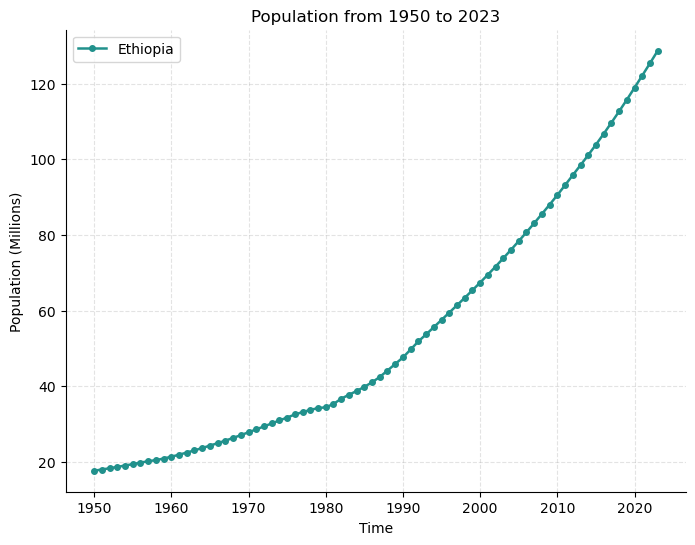

In [202]:
population_millions = load_population_millions()
years = np.arange(1950, 2024)

plt.figure(figsize=(8, 6))
colors = plt.cm.viridis(np.linspace(0, 1, 3))
color = colors[1]

plt.plot(years, population_millions, 'o-', color=color, linewidth=1.8, markersize=4, label='Ethiopia')

plt.xlabel('Time')
plt.ylabel('Population (Millions)')
plt.title('Population from 1950 to 2023')
plt.grid(True, linestyle='--', alpha=0.35)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend()

plt.show()

A clearly exponential trend can be seen, so it can be assumed that logistic effects will be negligible in a 10 year extrapolation. The mean $\mu$ and volatility $\sigma$ for this data can be found as described in the documentation.

In [203]:
R = np.log(population_millions[1:] / population_millions[:-1])
sigma = np.std(R)
mu = np.mean(R) + 0.5 * sigma**2

print(f'Percentage annual growth: {mu*100:.2f} %')
print(f'Percentage annual volatility: {sigma*100:.2f} %')

Percentage annual growth: 2.72 %
Percentage annual volatility: 0.63 %


By using the growth and volatility derived from the real world data, trajectories for the possible populations over a 10 year extrapolation can be simulated using the Euler-Maruyama method.

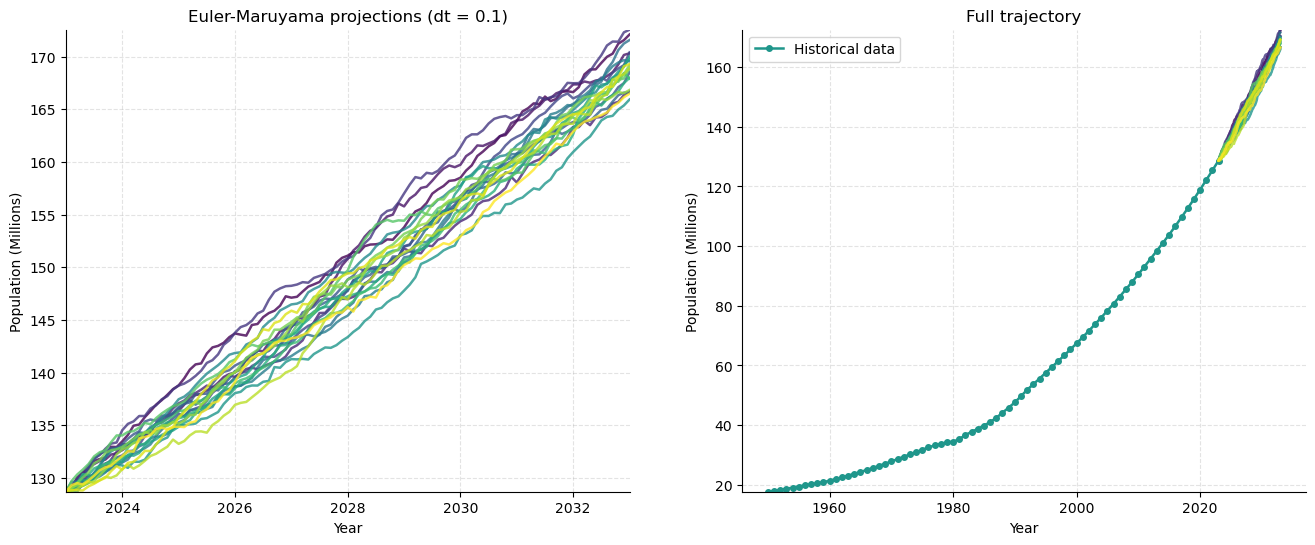

In [204]:
# Parameters
S0 = population_millions[-1]
T = 10

dt = 0.1
n_sims = 20

# Auxiliary values
n_steps = int(T / dt)
W = np.random.normal(0, np.sqrt(dt), (n_sims, n_steps))
future_years = np.linspace(2023, 2023 + T, n_steps + 1)

projections = euler_maruyama_GBM(mu, sigma, S0, T, W)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False, sharey=False)
colors = plt.cm.viridis(np.linspace(0, 1, n_sims))
historical_color = colors[len(colors) // 2]

for i, color in enumerate(colors):
    axes[0].plot(future_years, projections[i], color=color, alpha=0.8, linewidth=1.8)

axes[0].set_title(f"Euler-Maruyama projections (dt = {dt})")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Population (Millions)")
axes[0].set_xlim(future_years[0], future_years[-1])
axes[0].set_ylim(min(projections.min(), S0), max(projections.max(), S0))
axes[0].grid(True, linestyle="--", alpha=0.35)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].plot(years, population_millions, 'o-', color=historical_color, linewidth=1.8, markersize=4, label='Historical data')
for i, color in enumerate(colors):
    axes[1].plot(future_years, projections[i], color=color, alpha=0.8, linewidth=1.8)

axes[1].set_title("Full trajectory")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Population (Millions)")
axes[1].set_ylim(min(np.min(population_millions), np.min(projections)), max(np.max(population_millions), np.max(projections)))
axes[1].grid(True, linestyle="--", alpha=0.35)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].legend()

plt.show()

The plot above shows 20 simulations. However, if a much greater number of simulations is run, quantiles, and subsequently confidence intervals for the simulated paths can be found. Furthermore, the results for both a coarse and fine timestep $dt$ are shown, to see the effect the higher computational cost of a smaller timestep has.

Coarse mean: 168.895 millions
Fine mean: 168.898 millions
Coarse 95% CI: [162.635, 175.449] millions
Fine 95% CI:   [162.382, 175.431] millions


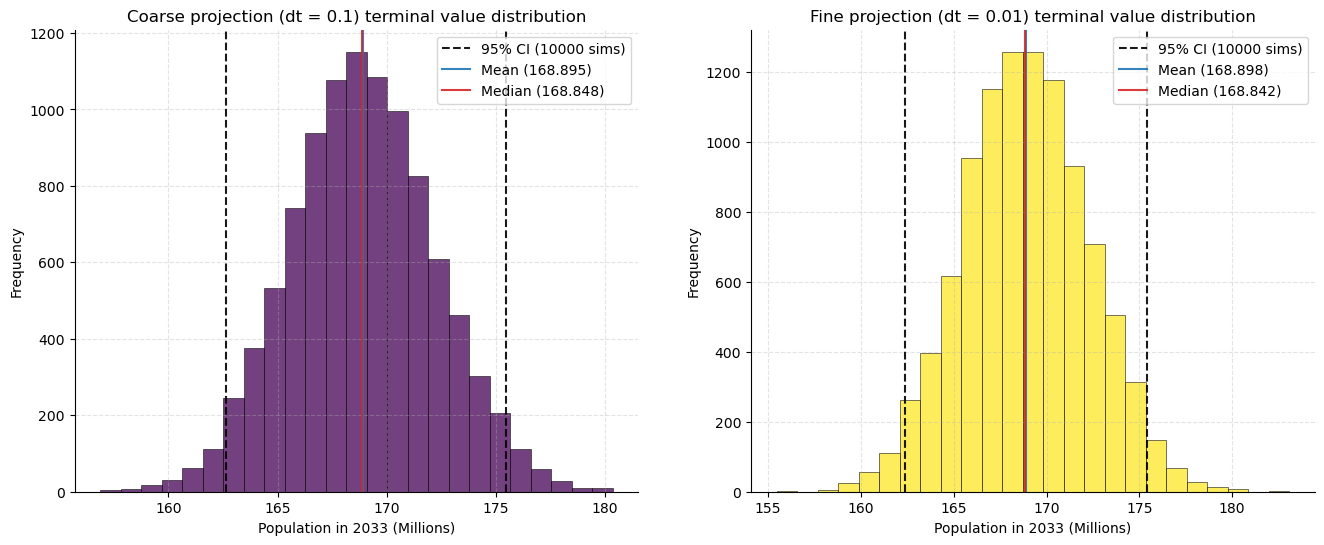

In [205]:
# Parameters
S0 = population_millions[-1]
T = 10
n_sims = 10_000

dt_coarse = 0.1
dt_fine = 0.01

# Auxiliary values
n_steps_coarse = int(T / dt_coarse)
n_steps_fine = int(T / dt_fine)

W_coarse = np.random.normal(0, np.sqrt(dt_coarse), (n_sims, n_steps_coarse))
W_fine = np.random.normal(0, np.sqrt(dt_fine), (n_sims, n_steps_fine))

# Calculations
coarse_paths = euler_maruyama_GBM(mu, sigma, S0, T, W_coarse)
fine_paths = euler_maruyama_GBM(mu, sigma, S0, T, W_fine)

coarse_final = coarse_paths[:, -1]
fine_final = fine_paths[:, -1]

coarse_mean = np.mean(coarse_final)
fine_mean = np.mean(fine_final)

print(f"Coarse mean: {coarse_mean:.3f} millions")
print(f"Fine mean: {fine_mean:.3f} millions")

coarse_ci = np.percentile(coarse_final, [2.5, 97.5])
fine_ci = np.percentile(fine_final, [2.5, 97.5])

print(f"Coarse 95% CI: [{coarse_ci[0]:.3f}, {coarse_ci[1]:.3f}] millions")
print(f"Fine 95% CI:   [{fine_ci[0]:.3f}, {fine_ci[1]:.3f}] millions")

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.viridis(np.linspace(0, 1, 2))

for ax, values, label, ci, color, n in [
    (axes[0], coarse_final, f"Coarse projection (dt = {dt_coarse})", coarse_ci, colors[0], len(coarse_final)),
    (axes[1], fine_final, f"Fine projection (dt = {dt_fine})", fine_ci, colors[1], len(fine_final)),
]:
    mean_value = np.mean(values)
    median_value = np.median(values)

    ax.hist(values, bins=25, color=color, alpha=0.75, edgecolor="black", linewidth=0.5)
    ax.axvline(ci[0], color="black", linestyle="--", linewidth=1.5, alpha=0.9, label=f"95% CI ({n} sims)")
    ax.axvline(ci[1], color="black", linestyle="--", linewidth=1.5, alpha=0.9)
    ax.axvline(mean_value, color="tab:blue", linestyle="-", linewidth=1.5, alpha=0.9, label=f"Mean ({mean_value:.3f})")
    ax.axvline(median_value, color="tab:red", linestyle="-", linewidth=1.5, alpha=0.9, label=f"Median ({median_value:.3f})")
    ax.set_title(f"{label} terminal value distribution")
    ax.set_xlabel("Population in 2033 (Millions)")
    ax.set_ylabel("Frequency")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(loc="best")

plt.show()